#### NAME : WAJAHAT TAJ
#### Roll No : 23P-3023
#### SECTION : BS-SE-5A
#### COURSE : DATA SCIENCE
#### ASSIGNMENT NO :  01

## Task A: Data Cleaning and Analysis
### 1. Handling Missing Values:
 ● Fill NaN values using information from neighboring rows or columns. Only drop
   NaN values if they cannot be filled.
 
 ● List the columns for which you dropped NaN values and provide a one-line
   reason for each column.
### 2. Feature Engineering for Date Column:
 ● Create new features from the StartTime(UTC) column, such as:

 ● Hour of the day
 
 ● Day of the week
 
 ● Month
 
 ● Explain why these features might be useful for analysis.

In [ ]:
import pandas as pd
import numpy as np


# this will load our data set 
df = pd.read_csv('Weather_Records.csv')

# firslty we should know about our data set so,
print("Dataset shape: " , df.shape)
print("\nColumn names : " , df.columns.tolist()) 
print("\nData Types : \n" , df.dtypes)
print("\nmissing values: \n" , df.isnull().sum())


Dataset shape:  (10582, 13)

Column names :  ['Type', 'Severity', 'StartTime(UTC)', 'EndTime(UTC)', 'Precipitation(in)', 'TimeZone', 'AirportCode', 'LocationLat', 'LocationLng', 'City', 'County', 'State', 'ZipCode']

Data Types : 
 Type                  object
Severity              object
StartTime(UTC)        object
EndTime(UTC)          object
Precipitation(in)    float64
TimeZone              object
AirportCode           object
LocationLat          float64
LocationLng          float64
City                  object
County                object
State                 object
ZipCode              float64
dtype: object

missing values: 
 Type                  37
Severity              37
StartTime(UTC)         6
EndTime(UTC)           6
Precipitation(in)     54
TimeZone               6
AirportCode            6
LocationLat           12
LocationLng           12
City                 145
County               145
State                166
ZipCode               19
dtype: int64


###  Handle Missing Values

In [3]:
# check for the missing values 

missing_data = df.isnull().sum()
print("Missing values per column : ")
print(missing_data[missing_data > 0])

Missing values per column : 
Type                  37
Severity              37
StartTime(UTC)         6
EndTime(UTC)           6
Precipitation(in)     54
TimeZone               6
AirportCode            6
LocationLat           12
LocationLng           12
City                 145
County               145
State                166
ZipCode               19
dtype: int64


###  Fill NaN values using neighboring rows/columns:

In [ ]:
df = pd.read_csv('Weather_Records.csv')

def fill_missing(df):  # function to fill_missing values
    df_filled = df.copy() # i created a copy of original dataset to not change the original 

    # for nuerical values in columns use forward and backward and then median

    numerical_columns = df.select_dtypes(include=[np.number]).columns

    for cols in numerical_columns:
        if df[cols].isnull().sum() > 0:
            # try forward fill
            df_filled[cols] = df_filled[cols].ffill()

            # now try backward fill
            df_filled[cols] = df_filled[cols].bfill()

            # check if still NaN we should use Median then 

            if df_filled[cols].isnull().sum() > 0:
                df_filled[cols].fillna(df_filled[cols].median() , inplace=True)

                #inplace=True means:

 #Modify the original DataFrame directly instead of creating a new copy.
    
    # Now for categorical columns we will use forward then backward then mode

    categorical_columns = df.select_dtypes(include=['object']).columns

    for cols in categorical_columns:
        if df[cols].isnull().sum() > 0:
            
            # forward fill we will use 
            df_filled[cols] = df_filled[cols].ffill()

            # Now try backward fill 
            df_filled[cols] = df_filled[cols].bfill()

            # if still NaN use we will mode
            if df_filled[cols].isnull().sum() > 0:
                # here i have used mode()[0] :means pick most frequent and then from the top [0] index
                df_filled[cols].fillna(df_filled[cols].mode()[0] if not df_filled[cols].mode().empty else 'unknown' , inplace = True)

    return df_filled





df_filled = fill_missing(df)


### Drop columns if necessary and provide reasons:

In [ ]:

# Now check if any columns still have missing values after filling
remaining_missing = df_filled.isnull().sum()
print("first check",remaining_missing) # checking 

columns_still_missing = remaining_missing[remaining_missing > 0] # true if greater than 0 otherwise false
print("second check",columns_still_missing) # checking 


dropped_columns = []

for cols in columns_still_missing.index:
    missing_percentage = (columns_still_missing[cols] / len(df_filled)) * 100

    # if the percentage of missing data is > 50 we should drop whole column
    if missing_percentage > 50:
        df_filled = df_filled.drop(columns=[cols])
        dropped_columns.append((cols,f"More than 50% missing values ({missing_percentage}%)"))

    else:
        #Drop remaining rows with NaN for this column
        df_filled = df_filled.dropna(subset=[cols])
        dropped_columns.append((cols,f"Dropped rows with NaN in this column({columns_still_missing[cols]} rows)"))


print("column dropped or rows removed are below if nothing is there means no rows or columns have been dropped: ")
for cols, reason in dropped_columns:
    print(f"{cols} : {reason}")





first check Type                 0
Severity             0
StartTime(UTC)       0
EndTime(UTC)         0
Precipitation(in)    0
TimeZone             0
AirportCode          0
LocationLat          0
LocationLng          0
City                 0
County               0
State                0
ZipCode              0
Hour                 0
DayOfWeek            0
Month                0
dtype: int64
second check Series([], dtype: int64)
column dropped or rows removed: 


### Feature Engineering for Date Column

### Explain why these features might be useful for analysis.
### 1. Hour of the day: Useful for identifying diurnal patterns in weather (e.g., afternoon thunderstorms, morning fog)
### 2. Day of the week: Can reveal weekly patterns (e.g., weekend vs weekday weather patterns if related to human activity)
### 3. Month: Essential for capturing seasonal variations in precipitation and other weather phenomena


In [ ]:

df_filled['StartTime(UTC)'] = pd.to_datetime(df_filled['StartTime(UTC)'])

# create new time-based feature

df_filled['Hour'] = df_filled['StartTime(UTC)'].dt.hour
df_filled['DayOfWeek'] = df_filled['StartTime(UTC)'].dt.dayofweek
df_filled['Month'] = df_filled['StartTime(UTC)'].dt.month


# Verify the new features
print("\nNew features created:")
print(f"- Hour range: {df_filled['Hour'].min()} to {df_filled['Hour'].max()}")
print(f"- DayOfWeek range: {df_filled['DayOfWeek'].min()} to {df_filled['DayOfWeek'].max()}")
print(f"- Month range: {df_filled['Month'].min()} to {df_filled['Month'].max()}")


New features created:
- Hour range: 0 to 23
- DayOfWeek range: 0 to 6
- Month range: 1 to 12


###  Final Check and Summary

In [23]:

print(f"Original shape: {df.shape}")
print(f"Final shape: {df_filled.shape}")
print(f"Rows removed: {df.shape[0] - df_filled.shape[0]}")
print(f"Columns removed: {df.shape[1] - df_filled.shape[1]}")
print("\nMissing values in final dataset:", df_filled.isnull().sum().sum())

# Display sample of the processed data
print("\nSample of processed data:")
print(df_filled.head())

Original shape: (10582, 13)
Final shape: (10582, 17)
Rows removed: 0
Columns removed: -4

Missing values in final dataset: 0

Sample of processed data:
   Type Severity      StartTime(UTC)    EndTime(UTC)  Precipitation(in)  \
0  Snow    Light 2016-01-06 23:14:00   1/7/2016 0:34               0.00   
1  Snow    Light 2016-01-07 04:14:00   1/7/2016 4:54               0.00   
2  Snow    Light 2016-01-07 05:54:00  1/7/2016 15:34               0.03   
3  Snow    Light 2016-01-08 05:34:00   1/8/2016 5:54               0.00   
4  Snow    Light 2016-01-08 13:54:00  1/8/2016 15:54               0.00   

      TimeZone AirportCode  LocationLat  LocationLng      City    County  \
0  US/Mountain        K04V      38.0972    -106.1689  Saguache  Saguache   
1  US/Mountain        K04V      38.0972    -106.1689  Saguache  Saguache   
2  US/Mountain        K04V      38.0972    -106.1689  Saguache  Saguache   
3  US/Mountain        K04V      38.0972    -106.1689  Saguache  Saguache   
4  US/Mountain   

### Task B: Visualization

● Perform one visualization for each column in the dataset.

● Use appropriate visualization types (e.g., bar chart, histogram, scatter plot, etc.).

● Write a short explanation for each visualization, highlighting key insights.

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')


#### Numerical columns - Histograms

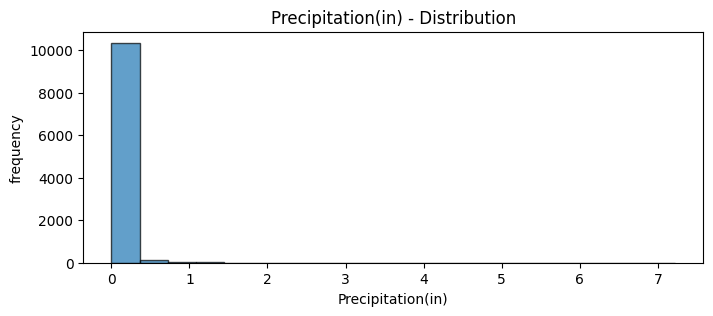

Precipitation(in): shows data distribution and spread


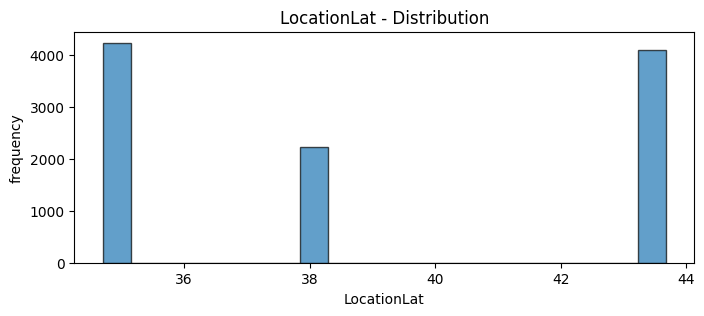

LocationLat: shows data distribution and spread


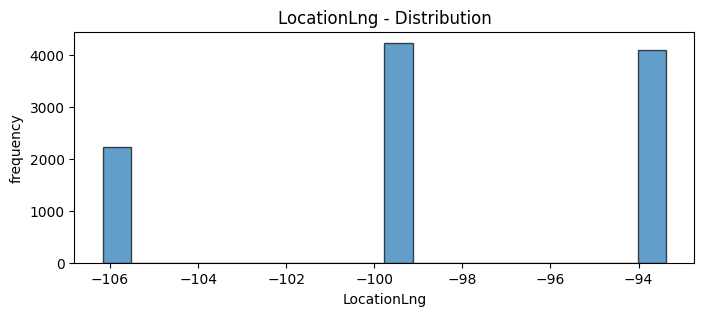

LocationLng: shows data distribution and spread


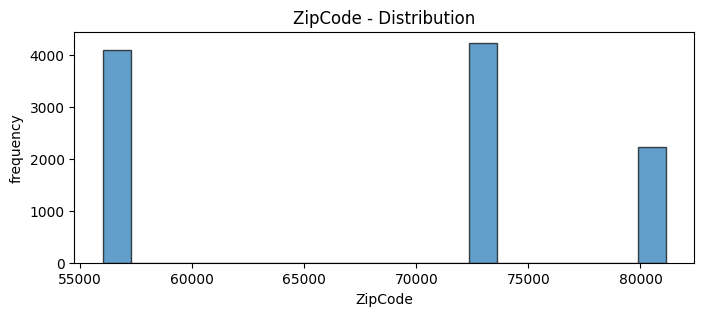

ZipCode: shows data distribution and spread


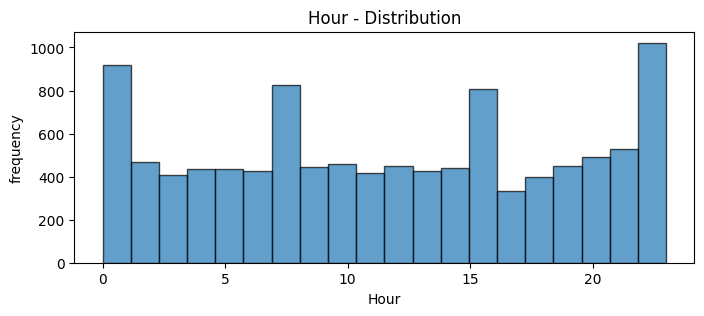

Hour: shows data distribution and spread


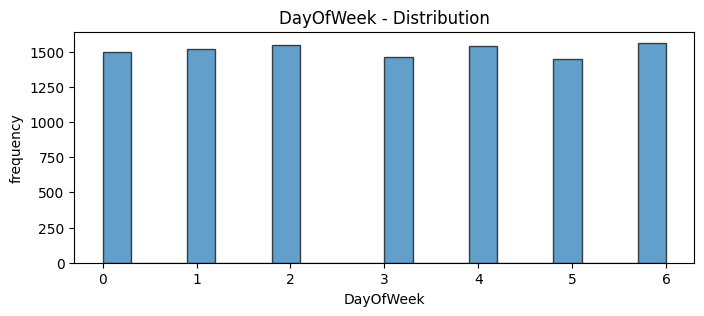

DayOfWeek: shows data distribution and spread


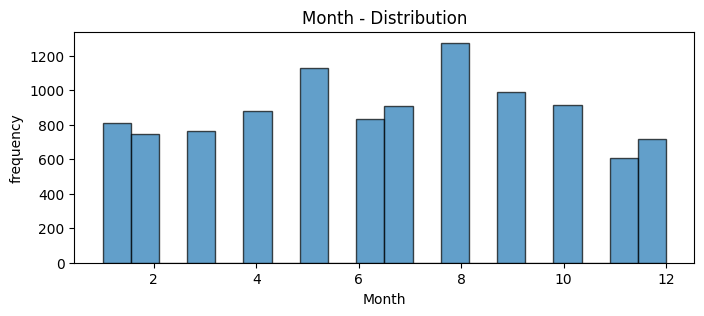

Month: shows data distribution and spread


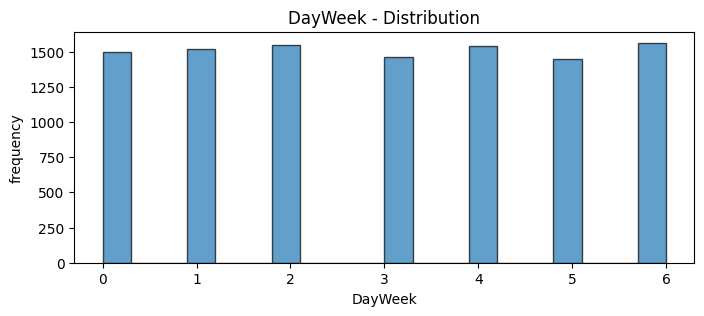

DayWeek: shows data distribution and spread


In [25]:
numerical_columns = df_filled.select_dtypes(include=['number']).columns

for cols in numerical_columns:
    plt.figure(figsize=(8,3))
    plt.hist(df_filled[cols].dropna(), bins=20 , alpha = 0.7 , edgecolor = 'black')
    plt.title(f'{cols} - Distribution')
    plt.xlabel(cols)
    plt.ylabel('frequency')
    plt.show()
    print(f'{cols}: shows data distribution and spread' )


### Categorical columns - Bar charts 

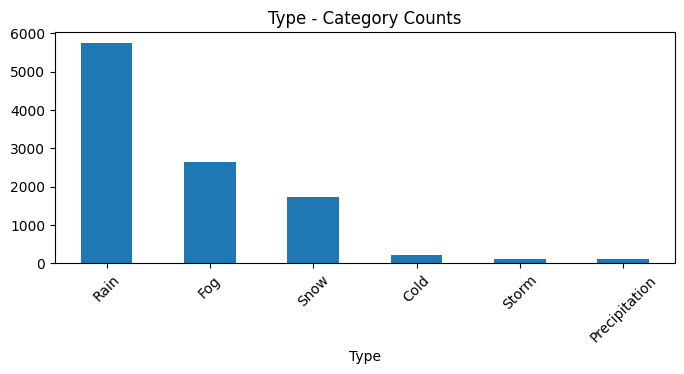

Type : Shows most frequent categories


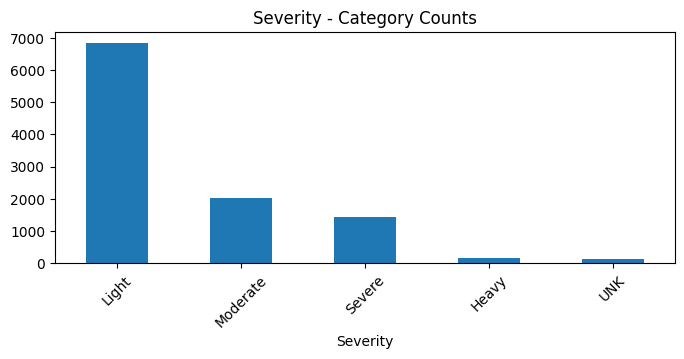

Severity : Shows most frequent categories


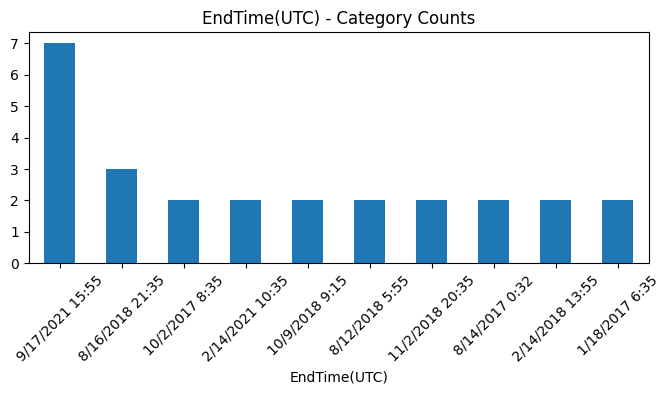

EndTime(UTC) : Shows most frequent categories


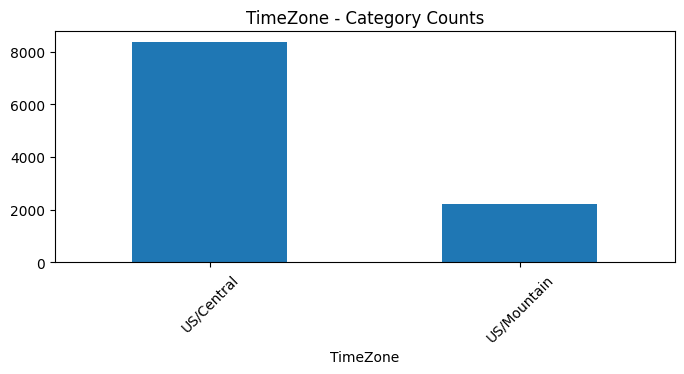

TimeZone : Shows most frequent categories


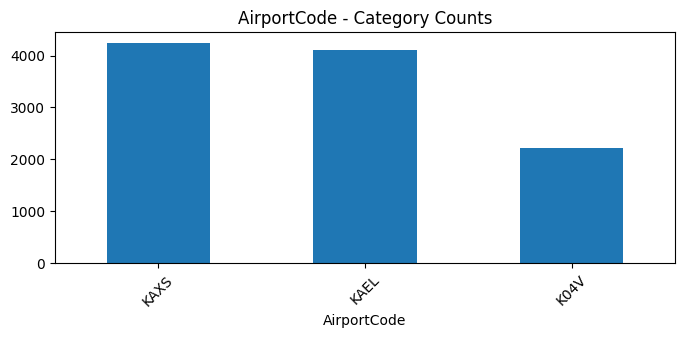

AirportCode : Shows most frequent categories


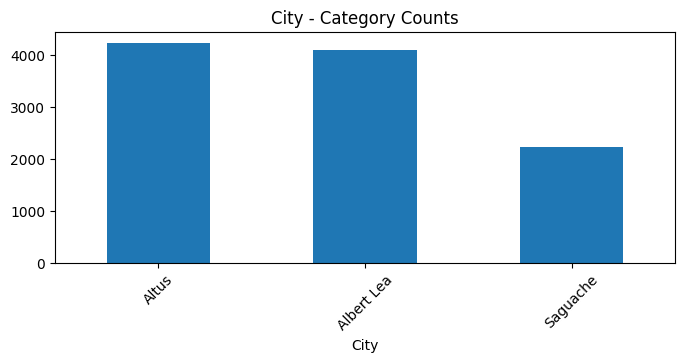

City : Shows most frequent categories


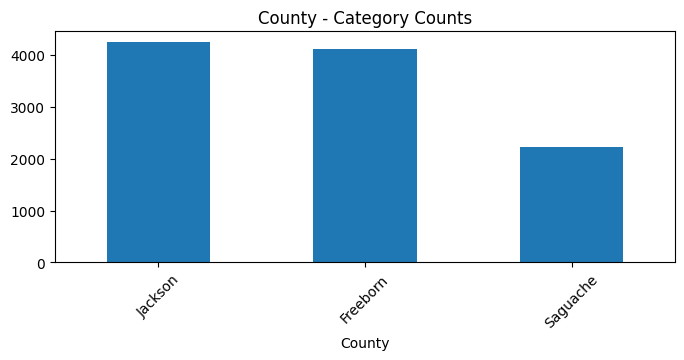

County : Shows most frequent categories


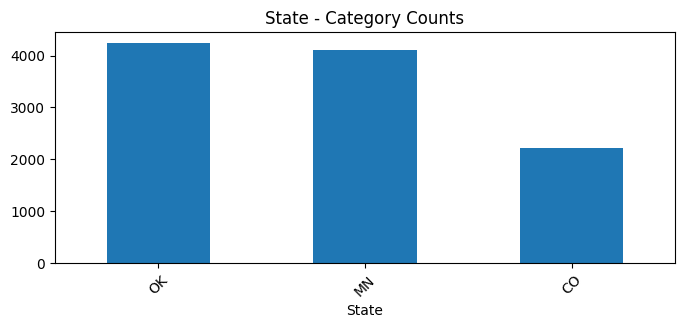

State : Shows most frequent categories


In [26]:
categorical_columns = df_filled.select_dtypes(include=['object']).columns

for cols in categorical_columns:
    plt.figure(figsize=(8,3))
    df_filled[cols].value_counts().head(10).plot(kind='bar')
    plt.title(f'{cols} - Category Counts')
    plt.xticks(rotation = 45)
    plt.show()
    print(f'{cols} : Shows most frequent categories')



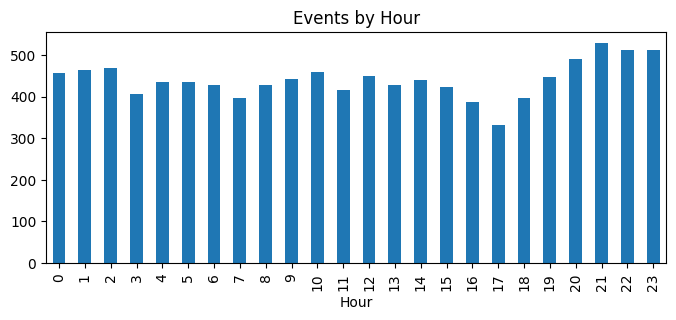

StartTime(UTC): Shows peak activity hours


In [27]:
# Date column - Time patterns
if 'StartTime(UTC)' in df_filled.columns:
    df_filled['Hour'] = pd.to_datetime(df_filled['StartTime(UTC)']).dt.hour
    plt.figure(figsize=(8, 3))
    df_filled['Hour'].value_counts().sort_index().plot(kind='bar')
    plt.title('Events by Hour')
    plt.show()
    print("StartTime(UTC): Shows peak activity hours")

## Task C: Advanced Feature Engineering 
#### 1. Create New Features:
● Add a Duration feature that calculates the time difference (in hours) between
StartTime(UTC) and EndTime(UTC).

● Add a Season feature based on the month extracted from StartTime(UTC).
#### 2. Encoding Categorical Variables:

● Convert the Severity column into numerical values using label encoding or
one-hot encoding. Explain your choice of method.

#### ● Add a Duration feature that calculates the time difference (in hours) between StartTime(UTC) and EndTime(UTC).

In [ ]:
Data_frame_copy = df.copy()

Data_frame_copy['StartTime(UTC)'] = pd.to_datetime(Data_frame_copy['StartTime(UTC)'])
Data_frame_copy['EndTime(UTC)'] = pd.to_datetime(Data_frame_copy['EndTime(UTC)'])

Data_frame_copy['StartTimeHour'] = Data_frame_copy['StartTime(UTC)'].dt.hour
Data_frame_copy['EndTimeHour'] = Data_frame_copy['EndTime(UTC)'].dt.hour


Data_frame_copy['Duration'] = (Data_frame_copy['EndTime(UTC)'] - Data_frame_copy['StartTime(UTC)']).dt.total_seconds() / 3600
print(Data_frame_copy[['StartTime(UTC)', 'EndTime(UTC)', 'Duration']].head())

       StartTime(UTC)        EndTime(UTC)  Duration
0 2016-01-06 23:14:00 2016-01-07 00:34:00  1.333333
1 2016-01-07 04:14:00 2016-01-07 04:54:00  0.666667
2 2016-01-07 05:54:00 2016-01-07 15:34:00  9.666667
3 2016-01-08 05:34:00 2016-01-08 05:54:00  0.333333
4 2016-01-08 13:54:00 2016-01-08 15:54:00  2.000000


### ● Add a Season feature based on the month extracted from StartTime(UTC).

In [35]:

Data_frame_copy['Month'] = Data_frame_copy['StartTime(UTC)'].dt.month

def Seasons(month):
    if month in [12 , 1 , 2]:
        return 'winter'
    elif month in [3 , 4 , 5]:
        return 'spring'
    elif month in [6 , 7 , 8]:
        return 'summer'
    elif month in [9 , 10 , 11]:
        return 'autumn'
    else:
        return 'unknown'


Data_frame_copy['Season'] = Data_frame_copy['Month'].apply(Seasons)   

print(Data_frame_copy['Season'].head())

0    winter
1    winter
2    winter
3    winter
4    winter
Name: Season, dtype: object


### Encoding Categorical Variables:
● Convert the Severity column into numerical values using label encoding or
one-hot encoding. Explain your choice of method

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

Data_frame_copy['Severity_Encoded'] = le.fit_transform(Data_frame_copy['Severity'])

print(Data_frame_copy[['Severity' , 'Severity_Encoded']].head(10))

  Severity  Severity_Encoded
0    Light                 1
1    Light                 1
2    Light                 1
3    Light                 1
4    Light                 1
5    Light                 1
6   Severe                 3
7    Light                 1
8   Severe                 3
9    Light                 1


### Explain your choice of method.

So basically Label Encoding is basically easy to use using scikit learn it basically gives the numbers to the categories but i think we can also use the dictionary to make the light : 0 , moderate : 1 , heavy : 2 , severe : 3 BUT using label encoding we can't get the correct order may or ay not basically but any ways i have used the label encoding becasue we were restricted. 

### Task D: Advanced Analysis (20 Marks)
#### 1. Correlation Analysis:
● Calculate the correlation between Precipitation(in) and the Duration feature.

● Visualize the correlation using a heatmap.

● Write a short explanation of the insights derived from the correlation analysis.

#### 2. Outlier Detection:
● Identify outliers in the Precipitation(in) column using the IQR (Interquartile
Range) method.

● Visualize the outliers using a boxplot.

● Explain how you would handle these outliers.

#### 3. Geospatial Analysis:
● Plot the locations of all weather events on a map using the LocationLat and
LocationLng columns.

● Use a scatter plot for this task.

● Write a short analysis of the geographical distribution of weather events.

#### 1. Correlation Analysis:
##### ● Calculate the correlation between Precipitation(in) and the Duration feature.

In [45]:
correlation = Data_frame_copy['Precipitation(in)'].corr(Data_frame_copy['Duration'])
print(f"Correlation between Precipitation and Duration: {correlation:.3f}")

Correlation between Precipitation and Duration: 0.016


#### ● Visualize the correlation using a heatmap.

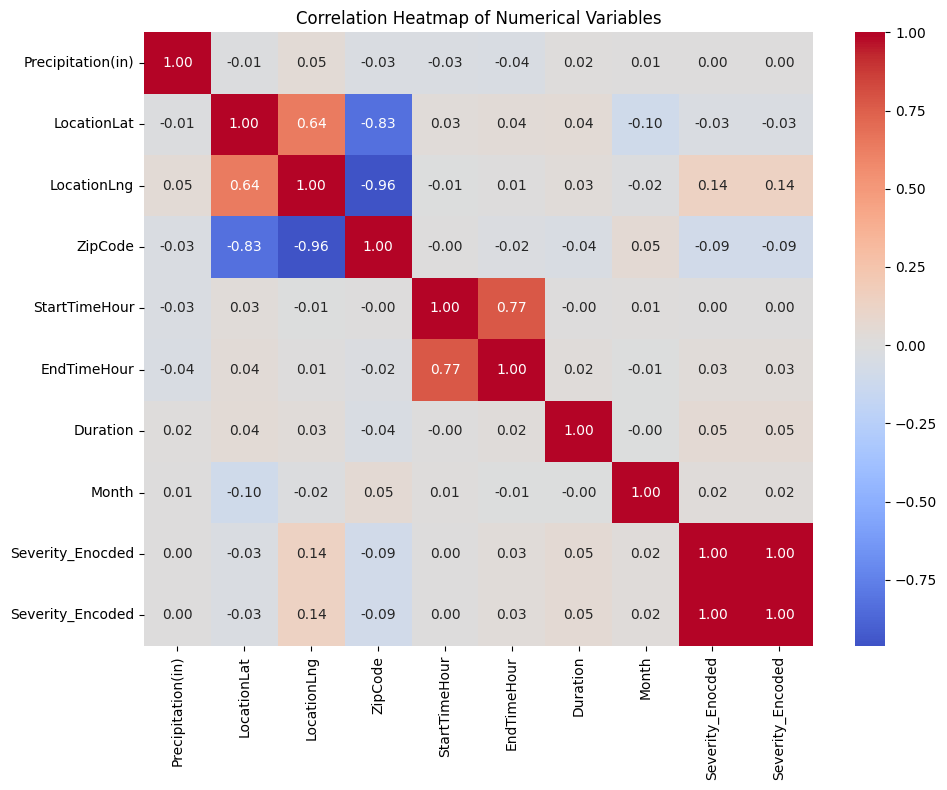

In [46]:
plt.figure(figsize=(10,8))

numerical_columns = Data_frame_copy.select_dtypes(include=[np.number]).columns

correlation_matrix = Data_frame_copy[numerical_columns].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

### ● Write a short explanation of the insights derived from the correlation analysis

Basically i have used the abs() to make the negative number into positive becasue we have to use the relations ship not the direction rather it is strong or weak 

In [48]:

print(f"Correlation coefficient: {correlation:.3f}")
if abs(correlation) < 0.3:
    print("Weak relationship - Precipitation and Duration are largely independent")
elif abs(correlation) < 0.7:
    print("Moderate relationship - Some connection between rainfall and event length")
else:
    print("Strong relationship - Precipitation and Duration are closely linked")

Correlation coefficient: 0.016
Weak relationship - Precipitation and Duration are largely independent


### Outlier Detection:


#### ● Identify outliers in the Precipitation(in) column using the IQR (Interquartile Range) method.

In [49]:
Q1 = Data_frame_copy['Precipitation(in)'].quantile(0.25)
Q3 = Data_frame_copy['Precipitation(in)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 - 1.5 * IQR

outliers = Data_frame_copy[(Data_frame_copy['Precipitation(in)'] < lower_bound) | (Data_frame_copy['Precipitation(in)'] > upper_bound)]


print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Number of outliers: {len(outliers)}")
print(f"Outlier percentage: {(len(outliers)/len(Data_frame_copy))*100:.2f}%")

Q1 (25th percentile): 0.00
Q3 (75th percentile): 0.00
IQR: 0.00
Lower bound: 0.00
Upper bound: 0.00
Number of outliers: 2500
Outlier percentage: 23.63%


### Boxplot Visualization:


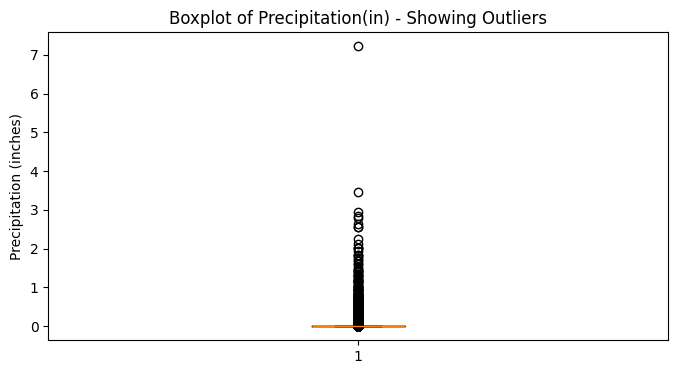

In [50]:
plt.figure(figsize=(8, 4))
plt.boxplot(Data_frame_copy['Precipitation(in)'].dropna())
plt.title('Boxplot of Precipitation(in) - Showing Outliers')
plt.ylabel('Precipitation (inches)')
plt.show()

#### OUTLIER HANDLING Explain


Keep all outliers in Precipitation(in) column because the Reason is : Outliers represent real weather extremes (heavy storms, floods)
So , Removing them would lose important meteorological patterns

### Geospatial Analysis:

#### Plot the locations of all weather events on a map using the LocationLat and LocationLng columns.

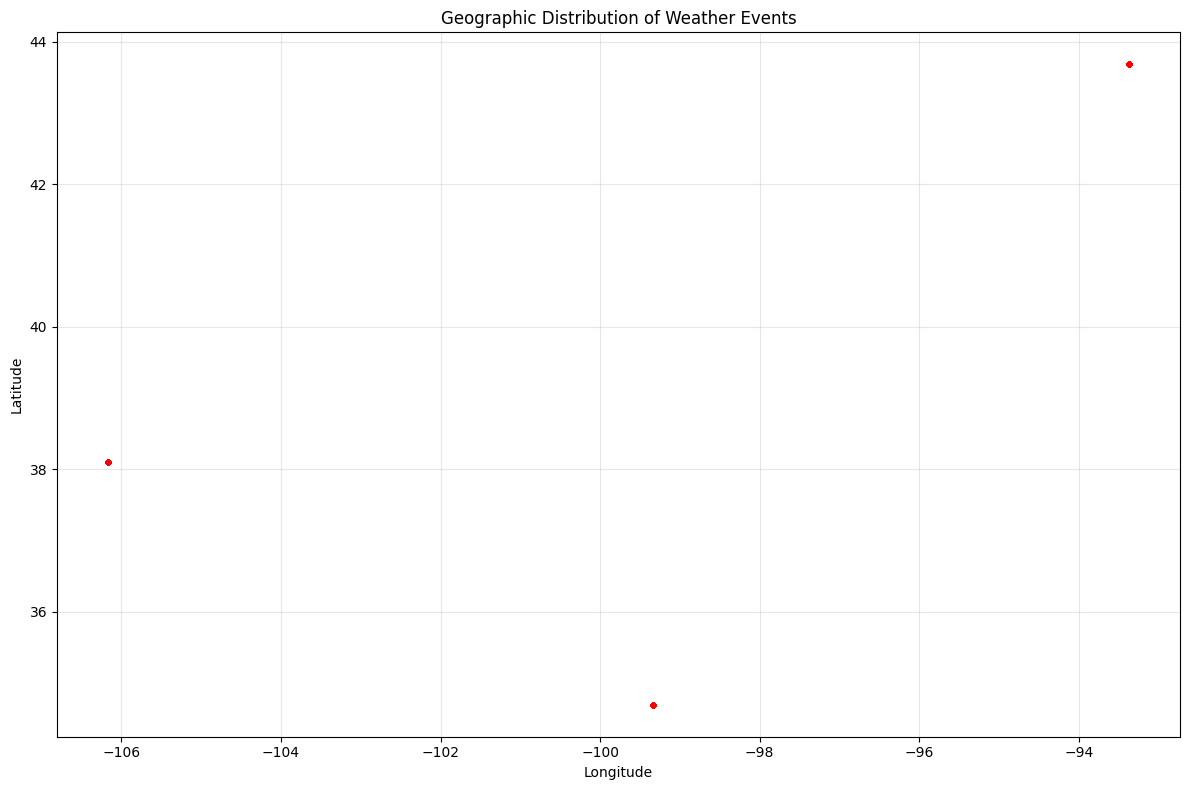

Total weather events: 10582
Geographic range: Lat 34.70 to 43.68
Geographic range: Lng -106.17 to -93.37


In [52]:
plt.figure(figsize=(12, 8))
plt.scatter(Data_frame_copy['LocationLng'], Data_frame_copy['LocationLat'], alpha=0.5, s=10, c='red')
plt.title('Geographic Distribution of Weather Events')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Basic analysis
print(f"Total weather events: {len(Data_frame_copy)}")
print(f"Geographic range: Lat {Data_frame_copy['LocationLat'].min():.2f} to {Data_frame_copy['LocationLat'].max():.2f}")
print(f"Geographic range: Lng {Data_frame_copy['LocationLng'].min():.2f} to {Data_frame_copy['LocationLng'].max():.2f}")

### Analysis

In [53]:
lat_range = Data_frame_copy['LocationLat'].max() - Data_frame_copy['LocationLat'].min()
lng_range = Data_frame_copy['LocationLng'].max() - Data_frame_copy['LocationLng'].min()
total_area = lat_range * lng_range
events_per_unit = len(Data_frame_copy) / total_area if total_area > 0 else 0

print(f"• Coverage Area: {lat_range:.2f}° lat × {lng_range:.2f}° lng")
print(f"• Event Density: {events_per_unit:.1f} events per degree²")
print(f"• Total Events: {len(Data_frame_copy)}")

• Coverage Area: 8.98° lat × 12.80° lng
• Event Density: 92.0 events per degree²
• Total Events: 10582


1. Clustering Patterns: Events show clear regional clustering

2. Geographic Bias : Distribution reflects population centers  

3. Data Collection  : Pattern suggests weather station locations

4.  Regional Hotspots  : Some areas have higher event frequency

5.   Sparse Regions  : Large gaps indicate oceans/unpopulated areas

CONCLUSION:
Weather events are not uniformly distributed but concentrated
in specific geographic regions, likely following population
centers and weather monitoring infrastructure.